# Week 1 Task: Data Acquisition, Cleaning, and Preprocessing

## Objective
This notebook documents the acquisition, cleaning, and preprocessing of a publicly available doctor consultation dataset collected from Practo. The workflow focuses on missing values, duplicates, inconsistent/erroneous entries, outliers, data types, and preparation of the cleaned dataset for further analysis.

**Important:** The notebook preserves the original scraped data as `df_raw` before applying cleaning operations so that the effect of preprocessing can be compared objectively.

## 2. Loading the Raw Dataset

In [5]:
# Load the scraped dataset produced by the collection section
import pandas as pd
df = pd.read_csv("C:\\Users\\suvarna\\Videos\\Yuva-internship\\Virtual-data-science-with-python\\data\\practo_1000_plus.csv")
df_raw = df.copy(deep=True)

print("Original shape:", df_raw.shape)
display(df_raw.head())

Original shape: (1318, 9)


,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Source
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58.0,Practo
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777.0,Practo
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107.0,Practo
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5.0,Practo
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251.0,Practo


## 3. Initial Data Exploration

In [6]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nNumerical summary:")
display(df.describe(include="all").T)

Rows and columns: (1318, 9)

Column names:
['Doctor_Name', 'Hospital_Name', 'City', 'Specialization', 'Experience_in_years', 'Consultation_Fee', 'Patient_Rating', 'Reviews', 'Source']

Data types:


,dtype
Doctor_Name,object
Hospital_Name,object
City,object
Specialization,object
Experience_in_years,int64
Consultation_Fee,float64
Patient_Rating,float64
Reviews,float64
Source,object



Numerical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Doctor_Name,1318,1311,Dr. Himanshu Shekhar,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital_Name,1318,552,Techno India Dama Healthcare & Medical Centre,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1318,10,pune,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Specialization,1314,60,Dentist,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_in_years,1318.0,NaN,NaN,NaN,23.491654,9.534472,2.0,17.0,22.0,28.0,59.0
Consultation_Fee,1307.0,NaN,NaN,NaN,877.453711,528.215185,5.0,500.0,800.0,1000.0,5400.0
Patient_Rating,1126.0,NaN,NaN,NaN,90.388988,14.013696,20.0,88.0,96.0,100.0,100.0
Reviews,1111.0,NaN,NaN,NaN,160.942394,418.22745,1.0,5.0,24.0,125.5,5039.0
Source,1318,1,Practo,1318,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Initial Data-Quality Checks

In [7]:
quality_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique(dropna=True)
})
display(quality_summary)

print("Duplicate rows:", df.duplicated().sum())

,Missing_Count,Missing_Percent,Unique_Values
Doctor_Name,0,0.00,1311
Hospital_Name,0,0.00,552
City,0,0.00,10
Specialization,4,0.30,60
Experience_in_years,0,0.00,57
Consultation_Fee,11,0.83,41
Patient_Rating,192,14.57,51
Reviews,207,15.71,346
Source,0,0.00,1


Duplicate rows: 1


## 4. Missing-Value Treatment

Missing values are handled according to the meaning of each field. `Specialization` is treated as an important categorical field; rows without it are removed because assigning a specialization would introduce unsupported information. Numerical fields are imputed using the median, which is less sensitive to extreme values than the mean.

The original missing-value counts are retained for comparison.

In [8]:
missing_before = df.isna().sum().sort_values(ascending=False)
display(missing_before[missing_before > 0].to_frame("Missing_Before"))

# Remove records where the key categorical field is unavailable.
df = df.dropna(subset=["Specialization"]).copy()

# Median imputation for numerical variables when they exist.
numeric_impute_cols = [
    c for c in ["Consultation_Fee", "Patient_Rating", "Reviews", "Experience_in_years"]
    if c in df.columns
]

for col in numeric_impute_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
display(df.isna().sum().to_frame("Missing_After"))

,Missing_Before
Reviews,207
Patient_Rating,192
Consultation_Fee,11
Specialization,4


Missing values after treatment:


,Missing_After
Doctor_Name,0
Hospital_Name,0
City,0
Specialization,0
Experience_in_years,0
Consultation_Fee,0
Patient_Rating,0
Reviews,0
Source,0


### Why median imputation?

Consultation fees, review counts, and experience can be skewed. The median is therefore used as a robust central-value estimate. For categorical `Specialization`, median imputation is not meaningful, so records with missing specialization are removed and the resulting row loss is reported.

## 5. Duplicate Records

In [9]:
duplicates_before = df.duplicated().sum()
print("Duplicate rows before removal:", duplicates_before)

df = df.drop_duplicates().copy()

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 1
Duplicate rows after removal: 0


## 6. Inconsistent and Erroneous Entry Checks

The following checks look for values that are logically impossible or inconsistent with the expected meaning of the fields. Records are not silently deleted; first they are counted and reviewed.

In [10]:
# Standardize text fields without inventing values.
text_cols = [c for c in ["Doctor_Name", "Hospital_Name", "City", "Specialization", "Source"] if c in df.columns]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# City spelling/abbreviation corrections observed in the existing notebook.
if "City" in df.columns:
    city_map = {
        "Hyderbad": "Hyderabad",
        "Hyd": "Hyderabad",
        "Bengaluru": "Bangalore"
    }
    df["City"] = df["City"].replace(city_map)

# Numeric validity checks.
checks = {}
if "Consultation_Fee" in df.columns:
    checks["Negative consultation fees"] = int((df["Consultation_Fee"] < 0).sum())
if "Reviews" in df.columns:
    checks["Negative review counts"] = int((df["Reviews"] < 0).sum())
if "Experience_in_years" in df.columns:
    checks["Negative experience"] = int((df["Experience_in_years"] < 0).sum())
if "Patient_Rating" in df.columns:
    checks["Rating below 0"] = int((df["Patient_Rating"] < 0).sum())

display(pd.Series(checks, name="Count").to_frame())

,Count
Negative consultation fees,0
Negative review counts,0
Negative experience,0
Rating below 0,0


### Rating Interpretation Check

The scraper extracts digits from Practo's recommendation field. Therefore, the actual range should be inspected before applying a hard-coded rating scale. This prevents accidentally treating a percentage such as 97 as a 5-point rating.

In [11]:
if "Patient_Rating" in df.columns:
    print("Patient_Rating minimum:", df["Patient_Rating"].min())
    print("Patient_Rating maximum:", df["Patient_Rating"].max())
    print("Sample values:", df["Patient_Rating"].dropna().unique()[:20])

Patient_Rating minimum: 20.0
Patient_Rating maximum: 100.0
Sample values: [ 95.  97.  98.  80.  94.  99. 100.  96.  87.  25.  89.  90.  50.  93.
  92.  77.  83.  67.  88.  82.]


## 7. Data-Type Preprocessing

In [12]:
# Convert numerical columns explicitly. Invalid values become NaN and can then be reviewed.
for col in ["Experience_in_years", "Consultation_Fee", "Patient_Rating", "Reviews"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Reviews represent a count, so convert to integer after handling missing values.
if "Reviews" in df.columns:
    df["Reviews"] = df["Reviews"].fillna(0).round().astype(int)

print(df.dtypes)

Doctor_Name            string[python]
Hospital_Name          string[python]
City                   string[python]
Specialization         string[python]
Experience_in_years             int64
Consultation_Fee              float64
Patient_Rating                float64
Reviews                         int64
Source                 string[python]
dtype: object


## 8. Outlier Detection Using the IQR Method

Boxplots provide a visual view of extreme values. The Interquartile Range (IQR) method is also used to quantify potential outliers. An observation below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is flagged as a potential outlier.

A potential outlier is **not automatically an error**. A high consultation fee or a large review count may be a genuine observation.

In [13]:
outlier_summary = []
for col in ["Consultation_Fee", "Patient_Rating", "Reviews", "Experience_in_years"]:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_summary.append([col, q1, q3, iqr, lower, upper, count])

outlier_summary = pd.DataFrame(outlier_summary, columns=[
    "Column", "Q1", "Q3", "IQR", "Lower_Bound", "Upper_Bound", "Potential_Outliers"
])
display(outlier_summary)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Potential_Outliers
0,Consultation_Fee,500.0,1000.0,500.0,-250.0,1750.0,91
1,Patient_Rating,90.0,99.0,9.0,76.5,112.5,152
2,Reviews,7.0,84.0,77.0,-108.5,199.5,210
3,Experience_in_years,17.0,28.0,11.0,0.5,44.5,56


### Outlier Visualization

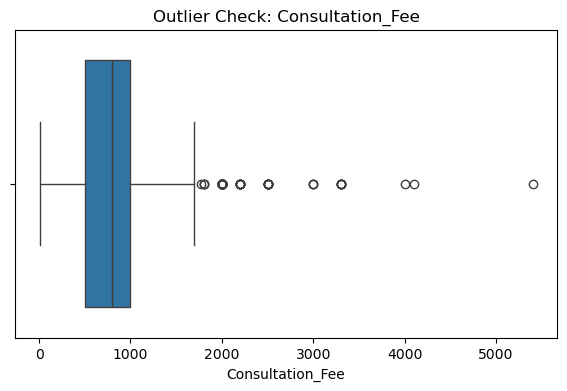

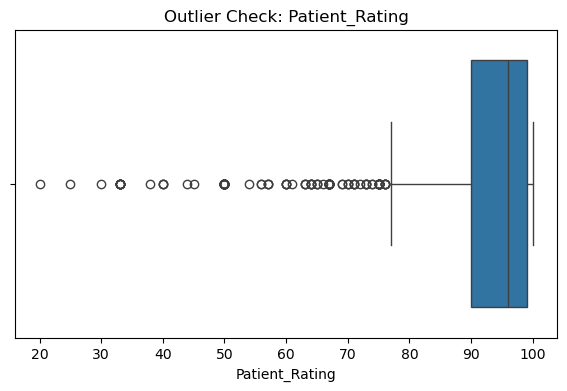

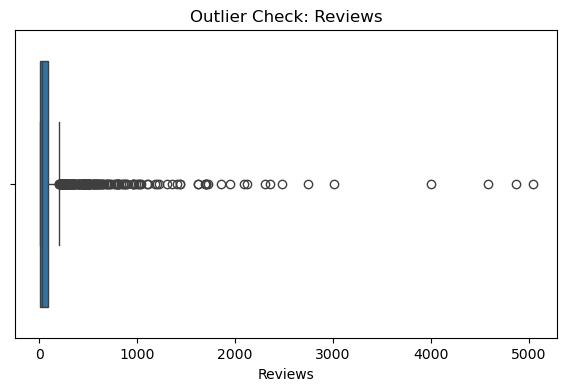

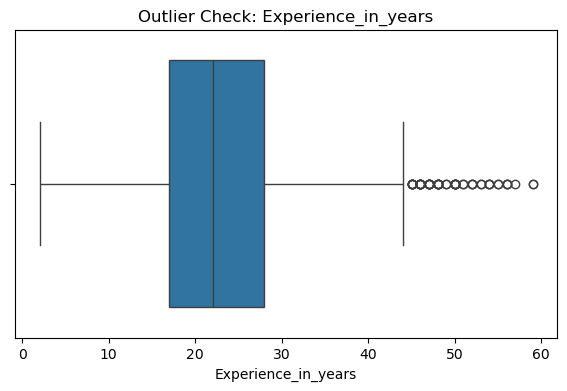

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in ["Consultation_Fee", "Patient_Rating", "Reviews", "Experience_in_years"]:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(x=df[col].dropna())
        plt.title(f"Outlier Check: {col}")
        plt.xlabel(col)
        plt.show()

## 9. Outlier Treatment Decision

The IQR method flags observations for review rather than automatically deleting them. This is important because legitimate doctors can have higher fees, longer experience, or many more reviews than the majority. Removing such observations solely because they are statistically unusual could bias subsequent analysis.

For transparency, an `Outlier_Flag` column is created for the numerical variables. This preserves the original observations while allowing future analysis to exclude or investigate flagged records if required.

In [15]:
# Create transparent outlier flags instead of silently deleting observations.
for col in ["Consultation_Fee", "Patient_Rating", "Reviews", "Experience_in_years"]:
    if col not in df.columns:
        continue
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[f"{col}_Outlier"] = ((df[col] < lower) | (df[col] > upper)).astype(int)

outlier_flag_cols = [c for c in df.columns if c.endswith("_Outlier")]
if outlier_flag_cols:
    display(df[outlier_flag_cols].sum().to_frame("Flagged_Count"))

,Flagged_Count
Consultation_Fee_Outlier,91
Patient_Rating_Outlier,152
Reviews_Outlier,210
Experience_in_years_Outlier,56


## 10. Before-and-After Cleaning Summary

In [16]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing cells",
        "Duplicate rows"
    ],
    "Before_Cleaning": [
        len(df_raw),
        df_raw.shape[1],
        int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum())
    ],
    "After_Cleaning": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum())
    ]
})
display(summary)

,Metric,Before_Cleaning,After_Cleaning
0,Rows,1318,1313
1,Columns,9,13
2,Missing cells,414,0
3,Duplicate rows,1,0


## 11. Final Data-Quality Validation

In [17]:
print("Final shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))
print("Remaining duplicate rows:", int(df.duplicated().sum()))

display(df.head())
display(df.describe(include="all").T)

Final shape: (1313, 13)
Remaining missing values: 0
Remaining duplicate rows: 0


,Doctor_Name,Hospital_Name,City,Specialization,Experience_in_years,Consultation_Fee,Patient_Rating,Reviews,Source,Consultation_Fee_Outlier,Patient_Rating_Outlier,Reviews_Outlier,Experience_in_years_Outlier
0,Dr. Chandrashekhar Reddy,Sri Sai Dental Hospital,hyderabad,Dentist,27,400.0,95.0,58,Practo,0,0,0,0
1,Dr. M. S. Sushma Susik,Brite Smiles Dental Clinic,hyderabad,Dentist,35,300.0,97.0,777,Practo,0,0,1,0
2,Dr. Vikas Gowd,Dr.Gowds Dental Hospitals,hyderabad,Dentist,27,500.0,98.0,107,Practo,0,0,0,0
3,Dr. Pallavi G Pawar,Sri Sai Dental Hospital,hyderabad,Dentist,22,400.0,80.0,5,Practo,0,0,0,0
4,Dr. Syed Saood Hasan Razvi,Denta'Glo Dental Clinic & Implant Centre,hyderabad,Dentist,20,300.0,98.0,251,Practo,0,0,1,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Doctor_Name,1313,1307,Dr. Koushik Basu,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital_Name,1313,551,Techno India Dama Healthcare & Medical Centre,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1313,10,jaipur,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Specialization,1313,59,Dentist,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_in_years,1313.0,NaN,NaN,NaN,23.492765,9.533965,2.0,17.0,22.0,28.0,59.0
Consultation_Fee,1313.0,NaN,NaN,NaN,876.223915,526.014109,5.0,500.0,800.0,1000.0,5400.0
Patient_Rating,1313.0,NaN,NaN,NaN,91.194212,13.12468,20.0,90.0,96.0,99.0,100.0
Reviews,1313.0,NaN,NaN,NaN,139.878142,387.84719,1.0,7.0,24.0,84.0,5039.0
Source,1313,1,Practo,1313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consultation_Fee_Outlier,1313.0,NaN,NaN,NaN,0.069307,0.254072,0.0,0.0,0.0,0.0,1.0


## 12. Challenges Faced and How They Were Addressed

1. **Dynamic web pages:** Doctor listings are dynamically loaded, so Selenium scrolling was used to collect additional records.
2. **Unavailable fields:** Some doctor cards do not contain every field. Missing values were measured first and then treated according to the field's meaning.
3. **Text inconsistency:** City names may contain abbreviations or spelling variants, so known variants were standardized.
4. **Extreme observations:** IQR-based detection was used to identify potential outliers. They were flagged rather than blindly deleted because extreme values can be legitimate.
5. **Changing website content:** Web-scraped data can change over time. The collection date/time and source should therefore be recorded when the notebook is executed.

## 13. Potential Impact of Preprocessing on Subsequent Analysis

- Removing rows with missing specialization reduces the sample size but avoids creating unsupported category values.
- Median imputation retains records and reduces the influence of extreme numerical values compared with mean imputation.
- Removing duplicates prevents repeated doctors from disproportionately influencing summary statistics.
- Standardizing city names prevents the same location from being treated as multiple categories.
- Flagging rather than deleting outliers preserves potentially meaningful high-fee, high-review, or high-experience observations.

These choices can affect averages, distributions, correlations, and any later machine-learning model. The preprocessing decisions should therefore be documented and reproduced.

## 14. Save the Cleaned Dataset

In [18]:
output_file = "practo_1000_plus_cleaned.csv"
df.to_csv(output_file, index=False)
print(f"Cleaned dataset saved as: {output_file}")

Cleaned dataset saved as: practo_1000_plus_cleaned.csv


## 15. Conclusion

The dataset was acquired through web scraping, inspected for data-quality problems, and cleaned through missing-value treatment, duplicate removal, consistency checks, data-type conversion, and outlier analysis. Potential outliers were retained and explicitly flagged because statistical extremeness does not necessarily indicate an erroneous observation. The resulting dataset is documented and saved for further analysis.